<a href="https://colab.research.google.com/github/yashkapur0403/Yash_Kapur_ML_Lab_Work/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

(145, 32)
1            0
2            0
3            0
4            0
5            0
6            0
7            0
8            0
9            0
10           0
11           0
12           0
13           0
14           0
15           0
16           0
17           0
18           0
19           0
20           0
21           0
22           0
23           0
24           0
25           0
26           0
27           0
28           0
29           0
30           0
COURSE ID    0
GRADE        0
dtype: int64


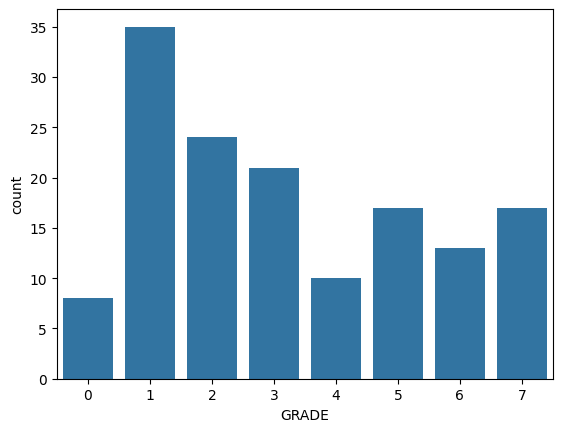

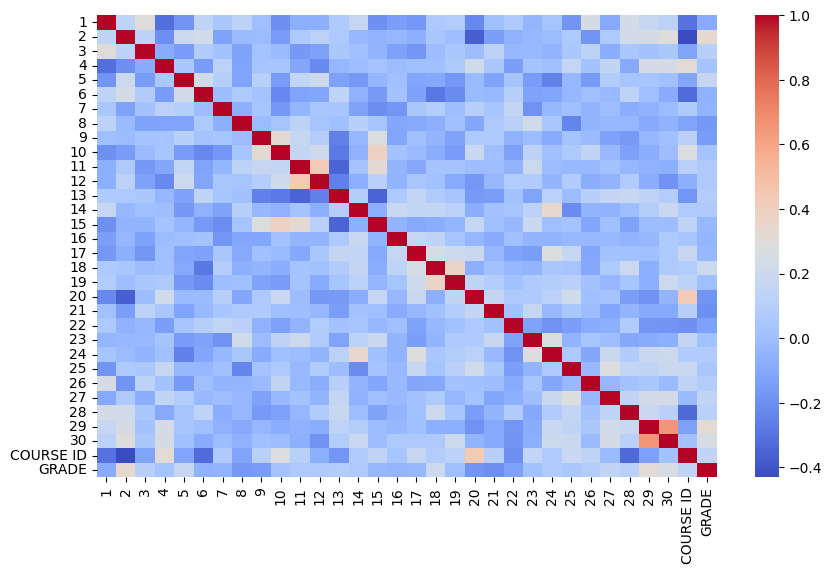

In [5]:
df = pd.read_csv('DATA (1).csv')
df = df.drop(columns=['STUDENT ID'])

df = df.apply(pd.to_numeric, errors='ignore')
df.fillna(df.median(numeric_only=True), inplace=True)

print(df.shape)
print(df.isnull().sum())

sns.countplot(x='GRADE', data=df)
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [6]:
X = df.drop('GRADE', axis=1)
y = df['GRADE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.20689655172413793
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.15      0.67      0.25         3
           2       0.00      0.00      0.00         4
           3       0.67      0.33      0.44         6
           4       0.00      0.00      0.00         3
           5       0.20      0.33      0.25         3
           6       0.50      0.25      0.33         4
           7       0.00      0.00      0.00         2

    accuracy                           0.21        29
   macro avg       0.19      0.20      0.16        29
weighted avg       0.24      0.21      0.19        29



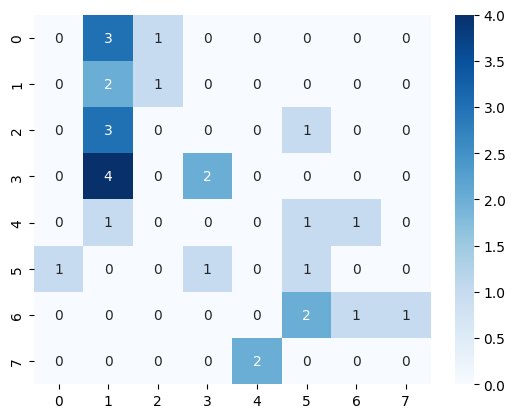

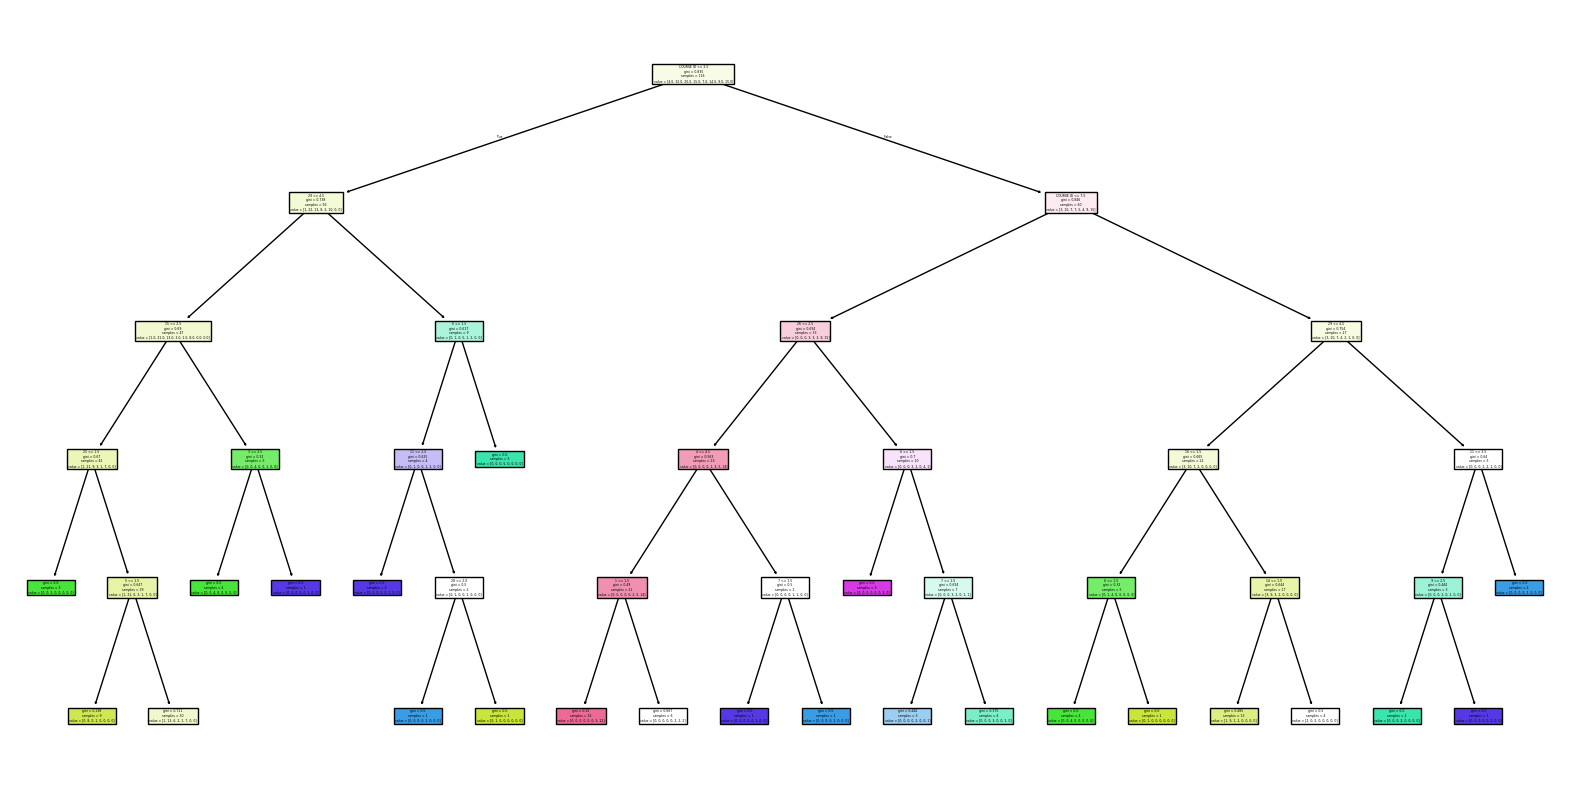

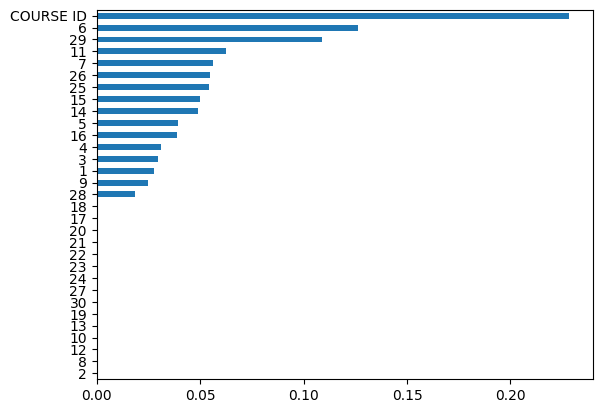

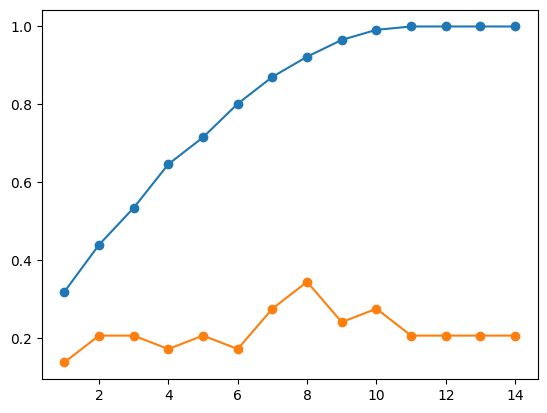

8


In [7]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X.columns, filled=True)
plt.show()

importance = pd.Series(dt.feature_importances_, index=X.columns).sort_values()
importance.plot(kind='barh')
plt.show()

depths = range(1, 15)
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.plot(depths, train_scores, marker='o')
plt.plot(depths, test_scores, marker='o')
plt.show()

print(depths[np.argmax(test_scores)])